1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score
)

2: Load Dataset

In [3]:
df = pd.read_csv("/content/drive/MyDrive/student_dataset.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,84.2,Low,Low,Yes,7.4,50.3,Medium,Yes,1,54.3
1,19.7,63.6,Medium,High,Yes,6.7,83.1,Low,Yes,2,59.4
2,24.4,98.4,Medium,Medium,Yes,8.0,63.5,Medium,Yes,0,63.8
3,29.6,88.6,Medium,High,Yes,6.3,57.5,Medium,Yes,2,61.0
4,19.1,91.5,High,Medium,Yes,6.2,66.0,Medium,Yes,2,60.7


3: Rename Columns

In [4]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.columns

Index(['hours_studied', 'attendance', 'parental_involvement',
       'access_to_resources', 'extracurricular_activities', 'sleep_hours',
       'previous_scores', 'motivation_level', 'internet_access',
       'tutoring_sessions', 'final_exam_score'],
      dtype='object')

4: Handle Missing Values

In [5]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.drop_duplicates(inplace=True)

/tmp/ipykernel_1442/2087699225.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1442/2087699225.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

5: Create Pass/Fail Target

Assume:

Score ≥ 50 → Pass

Score < 50 → Fail

In [6]:
df["pass_fail"] = np.where(df["final_exam_score"] >= 50, 1, 0)

df["pass_fail"].value_counts()

,count
pass_fail,
1,5832
0,775


6: Encode Categorical Columns

In [7]:
encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

7: Select Features

In [8]:
X = df.drop(["final_exam_score", "pass_fail"], axis=1)

y = df["pass_fail"]

8: Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

9: Feature Scaling

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Logistic Regression

In [11]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

KNN

In [12]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

Random Forest

In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

13: Evaluation Function

In [14]:
def evaluate(name, y_true, pred):

    acc = accuracy_score(y_true, pred)

    f1 = f1_score(y_true, pred)

    return [name, acc, f1]

14: Compare Models

In [15]:
results = pd.DataFrame([

    evaluate("Logistic Regression", y_test, log_pred),

    evaluate("KNN", y_test, knn_pred),

    evaluate("Random Forest", y_test, rf_pred)

], columns=["Model","Accuracy","F1 Score"])

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.914523,0.952581
1,KNN,0.915280,0.953450
2,Random Forest,0.919818,0.955723


15: Best Model

In [16]:
results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,F1 Score
2,Random Forest,0.919818,0.955723
1,KNN,0.915280,0.953450
0,Logistic Regression,0.914523,0.952581


16: Confusion Matrix (Logistic)

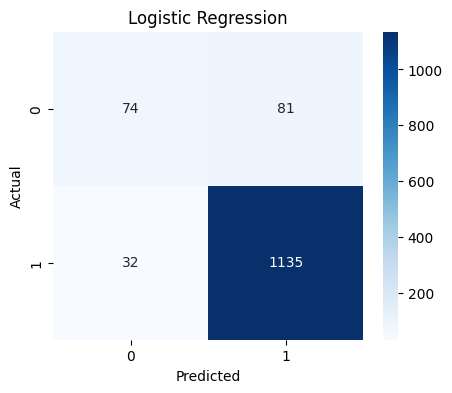

In [17]:
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

17: Confusion Matrix (KNN)

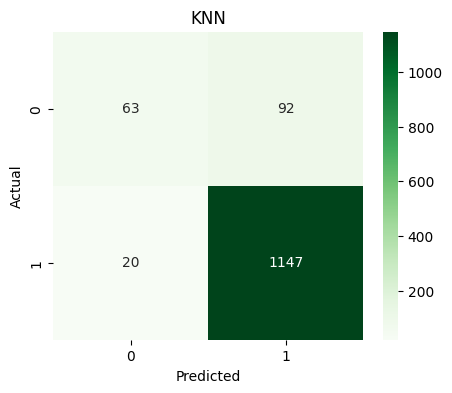

In [18]:
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens")

plt.title("KNN")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

18: Confusion Matrix (Random Forest)

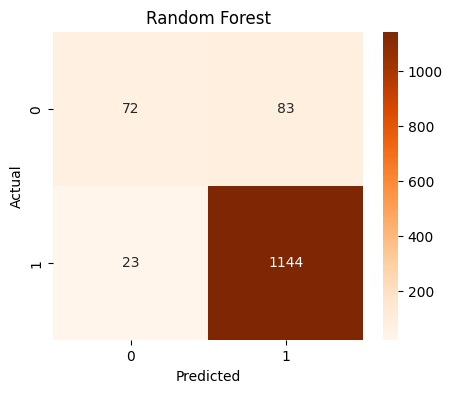

In [19]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Oranges")

plt.title("Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

19: Classification Reports

In [20]:
print("Logistic Regression")
print(classification_report(y_test, log_pred))

print("\nKNN")
print(classification_report(y_test, knn_pred))

print("\nRandom Forest")
print(classification_report(y_test, rf_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.70      0.48      0.57       155
           1       0.93      0.97      0.95      1167

    accuracy                           0.91      1322
   macro avg       0.82      0.72      0.76      1322
weighted avg       0.91      0.91      0.91      1322


KNN
              precision    recall  f1-score   support

           0       0.76      0.41      0.53       155
           1       0.93      0.98      0.95      1167

    accuracy                           0.92      1322
   macro avg       0.84      0.69      0.74      1322
weighted avg       0.91      0.92      0.90      1322


Random Forest
              precision    recall  f1-score   support

           0       0.76      0.46      0.58       155
           1       0.93      0.98      0.96      1167

    accuracy                           0.92      1322
   macro avg       0.85      0.72      0.77      1322
weighted avg       0.91      0.92 

20: Accuracy Comparison

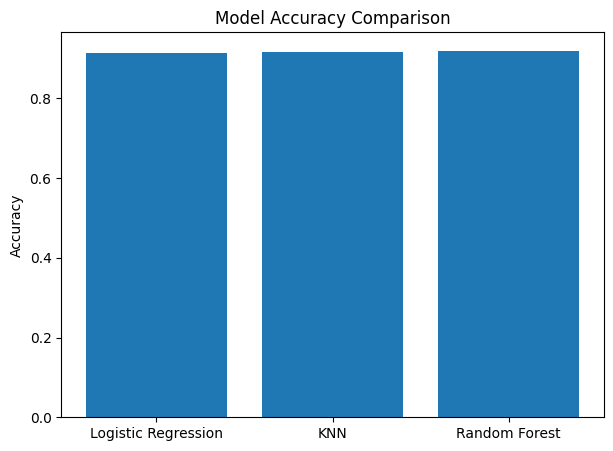

In [22]:
plt.figure(figsize=(7,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()